# Frequency and Keyness

## Housekeeping (no interaction required)

In [1]:
%pip install simplemma
%pip install nltk

/home/bode-wsl/projects/summerschool26/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.
/home/bode-wsl/projects/summerschool26/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [18]:
import os
import random
import time
from pathlib import Path

import pandas as pd
import nltk
import simplemma
from tqdm.notebook import tqdm

tqdm.pandas()
nltk.download("punkt_tab")
nltk.download("stopwords")

[nltk_data] Downloading package punkt_tab to /home/bode-
[nltk_data]     wsl/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /home/bode-
[nltk_data]     wsl/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [3]:
def confirm(question: str = "Do you want to execute this cell?"):
    while True:
        response = input(f"{question} (y/n): ").lower()
        if response in ["y", "yes"]:
            return True
        elif response in ["n", "no"]:
            return False
        else:
            print("Please enter 'y' or 'n'.")

In [4]:
confirm()

True

## Setup (Interaction required)

## Load the data


### <img src="https://cdn.simpleicons.org/googledrive" alt="💾" width=16> Load your own data from Google Drive

### <img src="https://cdn.svglogos.dev/logos/google-drive.svg" alt="💾" width=16> Load your own data from Google Drive

In [5]:
### ⬇️⬇️⬇️ 💽 Adjust here if you want to continue with your own query
CORPUS_NAME = "armenpflege"
LOAD_OWN_DATA = True
### ⬆️⬆️⬆️

In [6]:
IN_COLAB = 'COLAB_RELEASE_TAG' in os.environ
DATA_DIR = Path('/content/drive/MyDrive/ZBSummerSchool26/data') if IN_COLAB else Path('../data')

In [7]:
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    os.makedirs(DATA_DIR, exist_ok=True)

In [8]:
if LOAD_OWN_DATA:
    # RAWDATA_PATH = DATA_DIR / f"{CORPUS_NAME}.filtered.csv"
    # raw_df = pd.read_csv(RAWDATA_PATH, index_col="id")

    RAWDATA_PATH = DATA_DIR / f"{CORPUS_NAME}.filtered.parquet"
    raw_df = pd.read_parquet(RAWDATA_PATH)

### <img src="https://cdn.simpleicons.org/github" alt="🏫" width=16> <img src="https://www.zb.uzh.ch/themes/zb/assets/images/favicon-192.png" alt="💾" width=16> Load from Github

In [9]:
if not LOAD_OWN_DATA:
    RAWDATA_ORIGIN_URL = "https://github.com/pleyad/Summer-School-2026/raw/refs/heads/main/data/armensteuer_and_similars.filtered.csv"
    raw_df = pd.read_csv(RAWDATA_ORIGIN_URL, index_col="id")

    # RAWDATA_ORIGIN_URL = "https://github.com/pleyad/Summer-School-2026/raw/refs/heads/main/data/armensteuer_and_similars.filtered.parquet"
    # raw_df = pd.read_parquet(RAWDATA_ORIGIN_URL)

⚙️ Only for development, delete for summer school!

In [10]:
# raw_df = raw_df.reset_index()[["id", "meta.date", "meta.mediaTitle", "text.itemTypeLabel", "text.content", "text.contentLength"]]
# raw_df = raw_df.set_index("id")

### Parse data

In [11]:
raw_df["year"] = pd.to_datetime(raw_df["date"]).dt.year

## Preprocess Corpus

In [12]:
confirm("Do you want to preprocess the corpus?")

def sentencize(s: str) -> list[str]:
    sentences = nltk.tokenize.sent_tokenize(s, language="german")
    return sentences

def tokenize(s: str) -> list[str]:
    tokens = nltk.tokenize.word_tokenize(s, language="german")
    return tokens

def lemmatize(s: list[str]) -> list[str]:
    lemmatized = [simplemma.lemmatize(word, lang="de") for word in s]
    return lemmatized

# import re
# replacement_pairs = [
#     (re.compile(r"^Th"), "T"),
#     (re.compile(r"^th"), "t"),
#     (re.compile(r"th$"), "t"),
#     (re.compile(r"ß"), "s"),
# ]
# def normalize(s: list[str]) -> list[str]:
#     tokens = []
#     for tok in s:
#         for regex, replacement in replacement_pairs:
#             tok = regex.sub(replacement, tok)
#         tokens.append(tok)
#     return tokens

tqdm.pandas(desc="Applying sentencization")
raw_df["_sentences"] = raw_df["content"].progress_apply(sentencize)

tqdm.pandas(desc="Applying tokenization")
raw_df["tokens"] = raw_df["_sentences"].progress_apply(lambda sentences: [tokenize(sentence) for sentence in sentences])

#tqdm.pandas(desc="Applying lemmatization")
#raw_df["lemmas"] = raw_df["tokens"].progress_apply(lambda tokens: [lemmatize(normalize(token_list)) for token_list in tokens])

tqdm.pandas(desc="Applying lemmatization")
raw_df["lemmas"] = raw_df["tokens"].progress_apply(lambda tokens: [lemmatize(token_list) for token_list in tokens])

if LOAD_OWN_DATA:
    raw_df[["_sentences"]].to_parquet(DATA_DIR / f"{CORPUS_NAME}.filtered.sentences.parquet")
    raw_df[["lemmas"]].to_parquet(DATA_DIR / f"{CORPUS_NAME}.filtered.lemmas.parquet")
    raw_df[["tokens"]].to_parquet(DATA_DIR / f"{CORPUS_NAME}.filtered.tokens.parquet")


Applying sentencization:   0%|          | 0/2633 [00:00<?, ?it/s]

Applying tokenization:   0%|          | 0/2633 [00:00<?, ?it/s]

Applying lemmatization:   0%|          | 0/2633 [00:00<?, ?it/s]

Load the data

In [13]:
confirm = input("Do you want to load precomputed tokens and lemmas? (y/n) ")
assert confirm.lower() in ("y"), "❌ Cancelled."
print("✅ Loading precomputed tokens and lemmas...")

if LOAD_OWN_DATA:
    lemma_df = pd.read_parquet(DATA_DIR / f"{CORPUS_NAME}.filtered.lemmas.parquet")
    wordform_df = pd.read_parquet(DATA_DIR / f"{CORPUS_NAME}.filtered.tokens.parquet")
else:
    LEMMA_URL = "https://github.com/pleyad/Summer-School-2026/raw/refs/heads/main/data/armensteuer_and_similars.filtered.lemmas.parquet"
    lemma_df = pd.read_parquet(LEMMA_URL)

    TOKENS_URL = "https://github.com/pleyad/Summer-School-2026/raw/refs/heads/main/data/armensteuer_and_similars.filtered.tokens.parquet"
    wordform_df = pd.read_parquet(TOKENS_URL)

AssertionError: ❌ Cancelled.

In [14]:
if "lemmas" not in raw_df.columns:
    raw_df = raw_df.join(lemma_df)

if "tokens" not in raw_df.columns:
    raw_df = raw_df.join(wordform_df)

## Frequency Analyses

In [37]:
from collections import Counter



def count_tokens(df, column: str) -> Counter:
    counter = Counter()
    for doc in tqdm(df[column], desc="Counting Tokens", leave=False):
        for sentence in doc:
            for token in sentence:
                counter[token] += 1
    return counter

lemma_c = count_tokens(raw_df, "lemmas")

lemma_c.most_common(10)

Counting Tokens:   0%|          | 0/2633 [00:00<?, ?it/s]

[('der', 687727),
 (',', 441963),
 ('.', 350565),
 ('und', 146670),
 ('ein', 118535),
 ('sein', 118053),
 ('in', 106714),
 ('»', 100683),
 ('«', 95437),
 ('werden', 83025)]

### Compare Frequency across Time

In [ ]:
from typing import Dict
import matplotlib.pyplot as plt

class FrequencyAnalysisDiachronic:
    def __init__(self, df: pd.DataFrame, column: str, n_years: int):
        self.df = df.copy()
        self.column = column

        self.min_year = self.df["year"].min()
        self.max_year = self.df["year"].max()

        self.interval_counters = self.get_frequency_by_interval(n_years)
        self.intervals = list(self.interval_counters.keys())
        self.interval_total = {
            interval: sum(counter.values())
            for interval, counter
            in self.interval_counters.items()
        }

    def get_frequency_by_interval(self, n_years: int) -> Dict[str, Counter]:
        if n_years <= 0:
            raise ValueError("n_years must be a positive integer.")

        # Snap start to the nearest lower multiple of n_years
        start = (self.min_year // n_years) * n_years
        stop = self.max_year + n_years

        bins = list(range(start, stop + 1, n_years))
        labels = [f"{y}-{y + n_years - 1}" for y in bins[:-1]]

        # Assign each document to a year bucket
        # With n_years = 25:
        #   1833 -> 1825 -> "1825-1849"
        #   1900 -> 1900 -> "1900-1924"
        #   1898 -> 1875 -> "1875-1899"
        self.df["year_interval"] = pd.cut(self.df["year"], bins=bins, labels=labels, include_lowest=True)

        # Calculate counts for each interval
        interval_counters = {}
        # Filter out NaN intervals if any document year falls outside the defined bins
        for interval in tqdm(labels, desc="Iterating intervals"):
            group_df = self.df[self.df["year_interval"] == interval]
            interval_counters[interval] = count_tokens(group_df, column=self.column)
        return interval_counters

    def get_abs_frequencies_for_word(self, word: str) -> Dict[str, int]:
        frequencies = {}
        for interval in self.intervals:
            frequencies[interval] = self.interval_counters[interval][word]
        return frequencies

    def get_rel_frequencies_for_word(self, word: str) -> Dict[str, float]:
        frequencies = {}
        for interval in self.intervals:
            try:
                frequencies[interval] = self.interval_counters[interval][word] / self.interval_total[interval]
            except ZeroDivisionError:
                frequencies[interval] = 0.0
        return frequencies

    def get_norm_frequencies_for_word(self, word: str) -> Dict[str, float]:
        frequencies = self.get_rel_frequencies_for_word(word)
        frequencies = {interval: freq * 1000000 for interval, freq in frequencies.items()}
        return frequencies

    def plot_interval_totals(self):
        fig, ax = plt.subplots(figsize=(12, 3))

        ax.bar(self.intervals, [self.interval_total[interval] for interval in self.intervals])

        ax.tick_params(axis='x', rotation=45)
        # ax.legend(title="Words")
        ax.grid(True, linestyle='--', alpha=0.7)
        fig.tight_layout()
        ax.plot()

    def plot_relative_frequencies(self, words: list[str]):
        fig, ax = plt.subplots(figsize=(12, 6))

        for word in words:
            rel_freqs = self.get_rel_frequencies_for_word(word)
            series = pd.Series(rel_freqs)
            ax.plot(series.index.astype(str), series.values, label=word, marker='o', markersize=4)

        ax.tick_params(axis='x', rotation=45)
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.7)
        fig.tight_layout()
        ax.plot()


In [ ]:
fa_diachron = FrequencyAnalysisDiachronic(raw_df, "lemmas", 10)

Iterating intervals:   0%|          | 0/20 [00:00<?, ?it/s]

Counting Tokens:   0%|          | 0/1 [00:00<?, ?it/s]

Counting Tokens:   0%|          | 0/8 [00:00<?, ?it/s]

Counting Tokens:   0%|          | 0/3 [00:00<?, ?it/s]

Counting Tokens:   0%|          | 0/35 [00:00<?, ?it/s]

...

Counting Tokens:   0%|          | 0/144 [00:00<?, ?it/s]

Counting Tokens:   0%|          | 0/58 [00:00<?, ?it/s]

Counting Tokens:   0%|          | 0/4 [00:00<?, ?it/s]

Counting Tokens:   0%|          | 0/12 [00:00<?, ?it/s]

Counting Tokens:   0%|          | 0/3 [00:00<?, ?it/s]

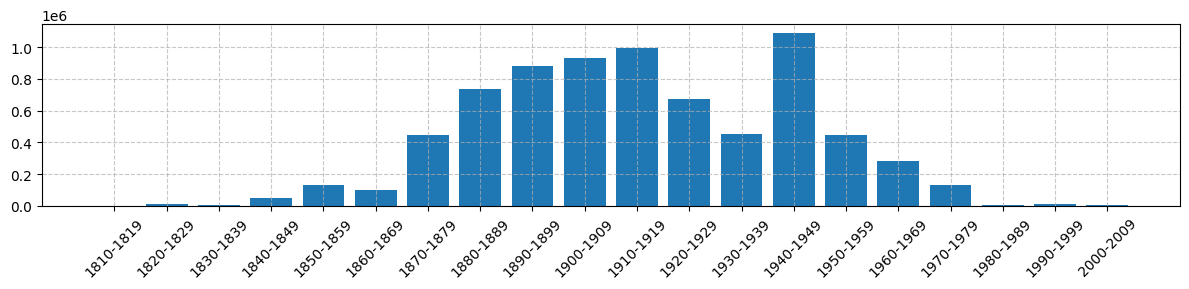

In [ ]:
fa_diachron.plot_interval_totals()

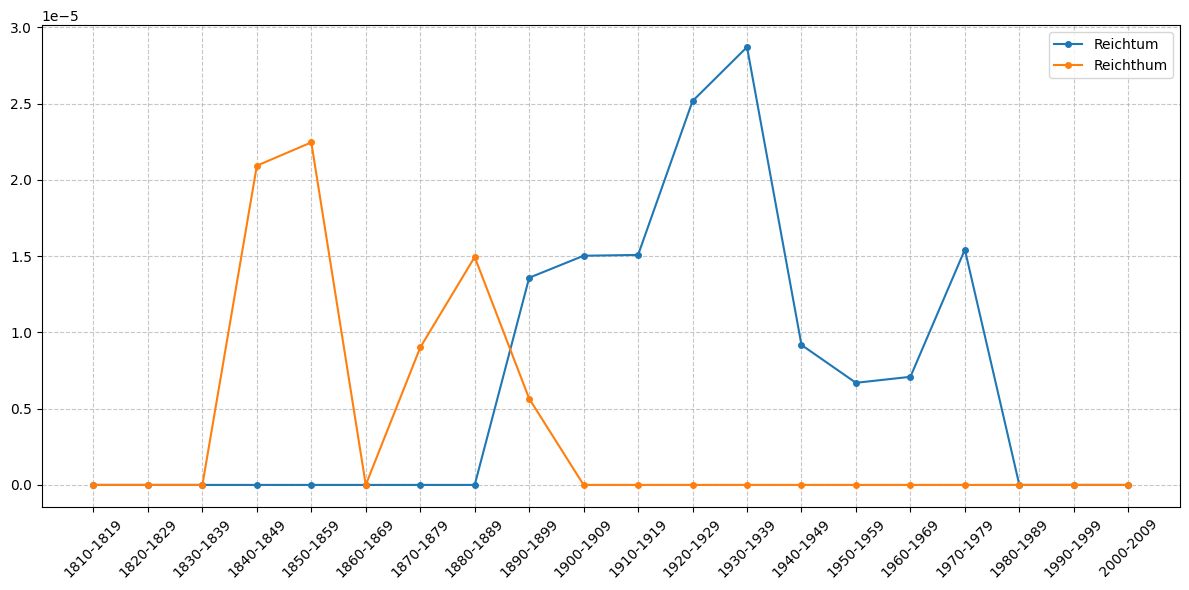

In [ ]:
fa_diachron.plot_relative_frequencies(["Reichtum",  "Reichthum"])

## Calculate Collocations

In [79]:
import math
from collections import Counter
from functools import lru_cache

SMALL = 1/2
STOPWORDS = set(nltk.corpus.stopwords.words("german"))
STOPWORDS = STOPWORDS.union(set("»«.,"))

class CollocationEngine:
    def __init__(self, df: pd.DataFrame, column: str, window: int = 5, mask_stopwords: bool = False):
        self.df = df.copy()
        self.column = column
        self.window = window
        self.mask_stopwords = mask_stopwords
        
        # How often is a token a node in the corpus?
        self.node_counts = count_tokens(self.df, column=self.column)
        if self.mask_stopwords:
            stopword_count = sum(count for token, count in self.node_counts.items() if token in STOPWORDS)
            for stopword in STOPWORDS:
                self.node_counts.pop(stopword, None)
            self.node_counts["<STOPWORD>"] = stopword_count

        self.total_tokens = sum(self.node_counts.values())
        
        # How often is a token a collocate of any other token? 
        self.collocate_counts = Counter({token: self.window * 2 * count for token, count in self.node_counts.items()})

        # Count window-sized chunks where the node token appears in the central position.
        self.total_windows = self.total_tokens - (self.window * 2 - 1)
     
    @lru_cache(maxsize=128)
    def get_collocations_for_word(self, node: str) -> pd.DataFrame:

        collocation_df = pd.DataFrame(columns=[
            "collocate",
            "o_n_c",
            "o_n_xc",
            "o_xn_c",
            "o_xn_xc",
            "o_n",
            "o_c",
            "e_n_c",
            "e_n_xc",
            "e_xn_c",
            "e_xn_xc",
            "llr",
            "lr",
            "mi",
        ])

        o_n = self.node_counts.get(node, 0)
        if o_n == 0:
            print(f"⚠️ The word '{node}' does not appear in the corpus. No collocations to compute.")
            return collocation_df

        if node in STOPWORDS:
            print(f"⚠️ The word '{node}' is a stopword. Consider setting mask_stopwords=False to include it in collocation counts.")
            return collocation_df

        node_collocation_counts = Counter()
        
        for doc in tqdm(self.df[self.column], desc=f"Counting collocations for '{node}'", leave=False):
            full_text = [token for sentence in doc for token in sentence]
            if self.mask_stopwords:
                full_text = [token if token not in STOPWORDS else "<STOPWORD>" for token in full_text]
            for i, token in enumerate(full_text):
                if token == node:
                    start = max(i - self.window, 0)
                    end = min(i + self.window + 1, len(full_text))
                    collocates = full_text[start:i] + full_text[i + 1:end]
                    collocates = set(collocates)  # Avoid overcounting the same collocate multiple times in the same window
                    node_collocation_counts.update(collocates)

        rows = []
        for collocate, o_n_c in node_collocation_counts.items():
            o_c = self.collocate_counts.get(collocate, 0)

            # Observed contingency table values.
            o_n_c = o_n_c
            o_n_xc = o_n - o_n_c
            o_xn_c = o_c - o_n_c
            o_xn_xc = self.total_windows - (o_n + o_c - o_n_c)
            # Border Values

            o_n = o_n
            o_xn = self.total_windows - o_n

            # Expected contingency table values under independence.
            e_n_c = (o_n * o_c) / self.total_windows
            e_n_xc = (o_n * (self.total_windows - o_c)) / self.total_windows
            e_xn_c = ((self.total_windows - o_n) * o_c) / self.total_windows
            e_xn_xc = ((self.total_windows - o_n) * (self.total_windows - o_c)) / self.total_windows

            data = {
                "o_n_c": o_n_c,
                "o_n_xc": o_n_xc,
                "o_xn_c": o_xn_c,
                "o_xn_xc": o_xn_xc,
                "o_n": o_n,
                "o_c": o_c,
                "e_n_c": e_n_c,
                "e_n_xc": e_n_xc,
                "e_xn_c": e_xn_c,
                "e_xn_xc": e_xn_xc,
            }

            # LLR (Stefanowitsch 10.5281/zenodo.3735822, p. 227)
            llr = 0.0
            for node_presence in ["n", "xn"]:
                for collocate_presence in ["c", "xc"]:
                    o = data[f"o_{node_presence}_{collocate_presence}"]
                    e = data[f"e_{node_presence}_{collocate_presence}"]
                    if o > 0 and e > 0:
                        llr += o * math.log(o / e)
            llr *= 2

            # Log Ratio (Hardie 2014)

            logprob_n = math.log((o_n_c + SMALL) / (o_n + SMALL))  # Add-one smoothing
            logprob_xn = math.log((o_xn_c + SMALL) / (o_xn + SMALL))  # Add-one smoothing
            log_ratio_hardie = logprob_n - logprob_xn

            # Mutual Information (Stefanowitsch 10.5281/zenodo.3735822, p. 227)
            mi = math.log(o_n_c / e_n_c) 

            rows.append({
                "collocate": collocate,
                "o_n_c": o_n_c,
                "o_n_xc": o_n_xc,
                "o_xn_c": o_xn_c,
                "o_xn_xc": o_xn_xc,
                "o_n": o_n,
                "o_c": o_c,
                "e_n_c": e_n_c,
                "e_n_xc": e_n_xc,
                "e_xn_c": e_xn_c,
                "e_xn_xc": e_xn_xc,
                "llr": llr,
                "lr": log_ratio_hardie,
                "mi": mi,
            })

        colloc_df = pd.DataFrame(rows)
        colloc_df = colloc_df.sort_values(by="llr", ascending=False)
        return colloc_df

colloc_engine = CollocationEngine(raw_df, "lemmas", window=5, mask_stopwords=False)
colloc_df = colloc_engine.get_collocations_for_word("Wohlstand")
colloc_df


Counting Tokens:   0%|          | 0/2633 [00:00<?, ?it/s]

Counting collocations for 'Wohlstand':   0%|          | 0/2633 [00:00<?, ?it/s]

,collocate,o_n_c,o_n_xc,o_xn_c,o_xn_xc,o_n,o_c,e_n_c,e_n_xc,e_xn_c,e_xn_xc,llr,lr,mi
316,Parallelität,2,93,8,7382061,95,10,0.000129,94.999871,9.999871e+00,7.382059e+06,35.077358,10.031663,9.651263
0,der,70,25,6877200,504869,95,6877270,88.502592,6.497408,6.877181e+06,5.048875e+05,34.539230,-0.232671,-0.234537
2,und,42,53,1466658,5915411,95,1466700,18.874750,76.125250,1.466681e+06,5.915388e+06,28.806061,0.806445,0.799845
18,blühend,3,92,1017,7381052,95,1020,0.013126,94.986874,1.019987e+03,7.381049e+06,26.720461,5.583097,5.431755
105,allgemein,7,88,35373,7346696,95,35380,0.455300,94.544700,3.537954e+04,7.346689e+06,25.633615,2.796623,2.732709
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183,gut,1,94,67969,7314100,95,67970,0.874696,94.125304,6.796913e+04,7.314100e+06,0.017317,0.534089,0.133879
169,noch,2,93,149978,7232091,95,149980,1.930071,93.069929,1.499781e+05,7.232091e+06,0.002556,0.253482,0.035590
168,zur,2,93,157118,7224951,95,157120,2.021955,92.978045,1.571180e+05,7.224951e+06,0.000244,0.206973,-0.010917
260,;,4,91,312776,7069293,95,312780,4.025121,90.974879,3.127760e+05,7.069293e+06,0.000164,0.106272,-0.006260


,collocate,o_n_c,o_n_xc,o_xn_c,o_xn_xc,o_n,o_c,e_n_c,e_n_xc,e_xn_c,e_xn_xc,llr,lr,mi
316,Parallelität,2,93,8,7382061,95,10,0.000129,94.999871,9.999871e+00,7.382059e+06,35.077358,10.031663,9.651263
0,der,70,25,6877200,504869,95,6877270,88.502592,6.497408,6.877181e+06,5.048875e+05,34.539230,-0.232671,-0.234537
2,und,42,53,1466658,5915411,95,1466700,18.874750,76.125250,1.466681e+06,5.915388e+06,28.806061,0.806445,0.799845
18,blühend,3,92,1017,7381052,95,1020,0.013126,94.986874,1.019987e+03,7.381049e+06,26.720461,5.583097,5.431755
105,allgemein,7,88,35373,7346696,95,35380,0.455300,94.544700,3.537954e+04,7.346689e+06,25.633615,2.796623,2.732709
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183,gut,1,94,67969,7314100,95,67970,0.874696,94.125304,6.796913e+04,7.314100e+06,0.017317,0.534089,0.133879
169,noch,2,93,149978,7232091,95,149980,1.930071,93.069929,1.499781e+05,7.232091e+06,0.002556,0.253482,0.035590
168,zur,2,93,157118,7224951,95,157120,2.021955,92.978045,1.571180e+05,7.224951e+06,0.000244,0.206973,-0.010917
260,;,4,91,312776,7069293,95,312780,4.025121,90.974879,3.127760e+05,7.069293e+06,0.000164,0.106272,-0.006260


In [67]:
df_pre1920 = raw_df[raw_df["year"] < 1920]
df_post1920 = raw_df[raw_df["year"] >= 1920]
from typing import Literal

class CollocationComparer:
    def __init__(self, dfs: dict[str, pd.DataFrame], column: str, window: int = 5, mask_stopwords: bool = False):
        self.dfs = dfs
        self.column = column
        self.window = window
        self.mask_stopwords = mask_stopwords

        self.engines = {
            name: CollocationEngine(df, column=column, window=window, mask_stopwords=mask_stopwords)
            for name, df in dfs.items()
        }

    def compare_collocations_for_word(self, node: str, metric: Literal["llr", "lr", "mi"] = "llr") -> pd.DataFrame:
        colloc_dfs = {}
        for name, engine in self.engines.items():
            colloc_dfs[name] = engine.get_collocations_for_word(node)

        col_names = []
        col_names.append("Rank")
        for name in self.dfs.keys():
            col_names.append(f"{name}_collocate")
            col_names.append(f"{name}_{metric}")
        
        comparison_df = pd.DataFrame()

        for name, colloc_df in colloc_dfs.items():
            colloc_df = colloc_df.sort_values(by=metric, ascending=False).head(20)
            colloc_df = colloc_df.reset_index(drop=True)
            colloc_df = colloc_df[[f"collocate", metric, "o_n_c"]]
            colloc_df.columns = [f"{name}_collocate", f"{name}_{metric}", f"{name}_#"]
            comparison_df = pd.concat([comparison_df, colloc_df], axis=1)

        return comparison_df
            
        

dfs = {
    "pre1880": raw_df[raw_df["year"] < 1880],
    "1880-1920": raw_df[(raw_df["year"] >= 1880) & (raw_df["year"] < 1920)],
    "post1920": raw_df[raw_df["year"] >= 1920],
}

comparer = CollocationComparer(dfs, column="lemmas", window=5, mask_stopwords=True)
comparison_df = comparer.compare_collocations_for_word("Reichtum", metric="llr")
comparison_df

Counting Tokens:   0%|          | 0/332 [00:00<?, ?it/s]

Counting Tokens:   0%|          | 0/1016 [00:00<?, ?it/s]

Counting Tokens:   0%|          | 0/1285 [00:00<?, ?it/s]

⚠️ The word 'Reichtum' does not appear in the corpus. No collocations to compute.


Counting collocations for 'Reichtum':   0%|          | 0/1016 [00:00<?, ?it/s]

Counting collocations for 'Reichtum':   0%|          | 0/1285 [00:00<?, ?it/s]

,pre1880_collocate,pre1880_llr,pre1880_#,1880-1920_collocate,1880-1920_llr,1880-1920_#,post1920_collocate,post1920_llr,post1920_#
0,NaN,NaN,NaN,<STOPWORD>,54.612646,37,<STOPWORD>,77.104805,51
1,NaN,NaN,NaN,Hilfsmittel,33.202036,2,Werktätigen,32.827653,2
2,NaN,NaN,NaN,Schönheit,26.464251,2,Luxus,30.720980,2
3,NaN,NaN,NaN,Sozialdemokrat,25.324447,2,lieben,25.762589,2
4,NaN,NaN,NaN,Land,24.768939,3,groß,25.061437,4
5,NaN,NaN,NaN,Volksklaffen,22.966488,1,Oeffentlichlcit,22.135272,1
6,NaN,NaN,NaN,deretwegen,22.966488,1,Fürsorgeöffentlich-rechtlich,22.135272,1
7,NaN,NaN,NaN,Einlegearbeit,22.966488,1,zeltgemäßer,22.135272,1
8,NaN,NaN,NaN,rufel,22.966488,1,aucr,22.135272,1
9,NaN,NaN,NaN,Cruppi,22.966488,1,Eifindung,22.135272,1


In [ ]:
import math

def count_tokens(df, column: str) -> Counter:
    counter = Counter()
    for doc in tqdm(df[column], desc="Counting Tokens", leave=False):
        for sentence in doc:
            for token in sentence:
                counter[token] += 1
    return counter

class KeynessComparer:
    def __init__(self, df1: pd.DataFrame, df2: pd.DataFrame, column: str = "lemmas", freq_filter=5):
        self.df1 = df1
        self.df2 = df2
        self.column = column
        self.freq_filter = freq_filter

        self.counter1 = count_tokens(self.df1, self.column)
        self.counter2 = count_tokens(self.df2, self.column)

        self.total_tokens1 = sum(self.counter1.values())
        self.total_tokens2 = sum(self.counter2.values())

        # Apply the frequency filter
        self.counter1 = Counter({token: count for token, count in self.counter1.items() if count >= self.freq_filter})
        self.counter2 = Counter({token: count for token, count in self.counter2.items() if count >= self.freq_filter})

        self.df = self.build_contingency_df()

    def build_contingency_df(self) -> pd.DataFrame:
        all_tokens = set(self.counter1.keys()) | set(self.counter2.keys())
        data = []
        for token in tqdm(all_tokens, desc="Build Contingency Table"):
            observed_tok_1 = self.counter1[token]
            observed_tok_2 = self.counter2[token]
            observed_notok_1 = self.total_tokens1 - observed_tok_1
            observed_notok_2 = self.total_tokens2 - observed_tok_2

            # Expected frequencies under the null hypothesis of no association between token and corpus
            expected_tok_1 = (observed_tok_1 + observed_tok_2) * self.total_tokens1 / (self.total_tokens1 + self.total_tokens2)
            expected_tok_2 = (observed_tok_1 + observed_tok_2) * self.total_tokens2 / (self.total_tokens1 + self.total_tokens2)
            expected_notok_1 = (observed_notok_1 + observed_notok_2) * self.total_tokens1 / (self.total_tokens1 + self.total_tokens2)
            expected_notok_2 = (observed_notok_1 + observed_notok_2) * self.total_tokens2 / (self.total_tokens1 + self.total_tokens2)

            data.append({
                "token": token,
                "observed_tok_1": observed_tok_1,
                "observed_tok_2": observed_tok_2,
                "observed_notok_1": observed_notok_1,
                "observed_notok_2": observed_notok_2,
                "expected_tok_1": expected_tok_1,
                "expected_tok_2": expected_tok_2,
                "expected_notok_1": expected_notok_1,
                "expected_notok_2": expected_notok_2,
                "prevalent_1": True if observed_tok_1 > expected_tok_1 else False,
            })
        contingency_df = pd.DataFrame(data)
        return contingency_df

    def log_likelihood_ratio(self, contingency_row: pd.Series) -> float:
        G = 0.0
        for token_presence in ["tok", "notok"]:
            for corpus in ["1", "2"]:
                observed = contingency_row[f"observed_{token_presence}_{corpus}"]
                expected = contingency_row[f"expected_{token_presence}_{corpus}"]

                if observed > 0 and expected > 0:
                    G += observed * math.log(observed / expected)
        return 2 * G

    def log_ratio(self, contingency_row: pd.Series) -> float:
        observed_tok_1 = contingency_row["observed_tok_1"]
        observed_tok_2 = contingency_row["observed_tok_2"]
        logprob1 = math.log((observed_tok_1 + 1/2) / (self.total_tokens1 + 1/2))  # Add-one smoothing
        logprob2 = math.log((observed_tok_2 + 1/2) / (self.total_tokens2 + 1/2))  # Add-one smoothing

        return logprob1 - logprob2

    def build_keyness_df(self) -> pd.DataFrame:
        tqdm.pandas(desc="Calculating log likelihood ratio")
        self.df["llr"] = self.df.progress_apply(self.log_likelihood_ratio, axis=1)
        tqdm.pandas(desc="Calculating log ratio")
        self.df["log_ratio"] = self.df.progress_apply(self.log_ratio, axis=1)
        return self.df

In [ ]:
df_pre1920 = raw_df[raw_df["year"] < 1920]
df_post1920 = raw_df[raw_df["year"] >= 1920]

kf = KeynessComparer(df_pre1920, df_post1920)

In [ ]:
df_pre1920 = raw_df[raw_df["year"] < 1920]

df_tat = df_pre1920[df_pre1920["meta.mediaTitle"] == "Die Tat"]
df_nzz = df_pre1920[df_pre1920["meta.mediaTitle"] == "Neue Zürcher Zeitung"]
kf = KeynessComparer(df_tat, df_nzz, freq_filter=3)

In [ ]:
kf.__class__ = KeynessComparer

In [ ]:
kf.build_keyness_df()

In [ ]:
kf.df.sort_values("log_ratio", ascending=False).head(10)